# Vizualize the difference of performance between AF-Cluster and AlphaConformer

In [1]:
import Pkg
Pkg.build()

InterruptException: InterruptException:

In [1]:
using DataFrames, StatsPlots, Colors, CSV

#get the csv 
df_path="Compare_output_AF.csv"
df=DataFrames.DataFrame(CSV.File(df_path,
        comment="#", missingstring=["", "None"])) 
first(df,5)

Row,Folder,File,rmsd_apo_holo,min_apo,mean_apo,var_apo,min_holo,mean_holo,var_holo
,String31,String15,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1AKZ,1AKZ,1.5002,0.53728,6.74131,45.6555,1.04291,6.7492,44.148
2,1AKZ_AF_CLUSTER,1AKZ,1.5002,2.2767,13.732,58.4237,1.99558,13.6224,58.0012
3,1AKZ_AF_CLUSTER,1AKZ_U10,1.5002,0.971829,2.37733,0.526404,1.25064,2.31165,0.33791
4,1AKZ_AF_CLUSTER,1AKZ_U100,1.5002,0.49363,0.567974,0.00121571,1.23698,1.34127,0.00152258
5,1AKZ_AF_CLUSTER_template,1AKZ,1.5002,1.79782,13.5213,51.4714,1.77821,13.3829,50.2268


[0.5372800966467091, 2.2767041228240563, 0.6095639058662332]
Any[0.5372800966467091, 1.0429140436314184, 2.2767041228240563, 1.9955810610235794, 0.6095639058662332, 0.8741859828741932]


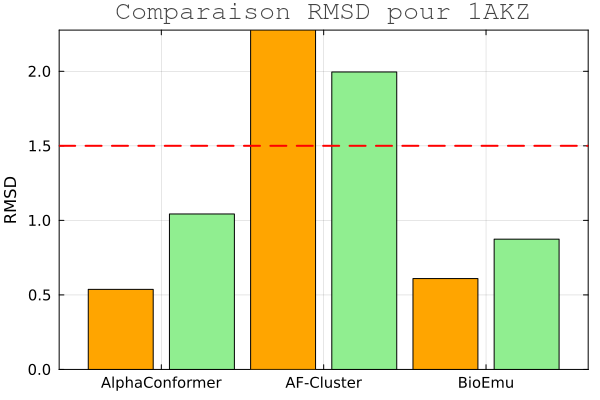

GKS: could not find font Arial.ttf


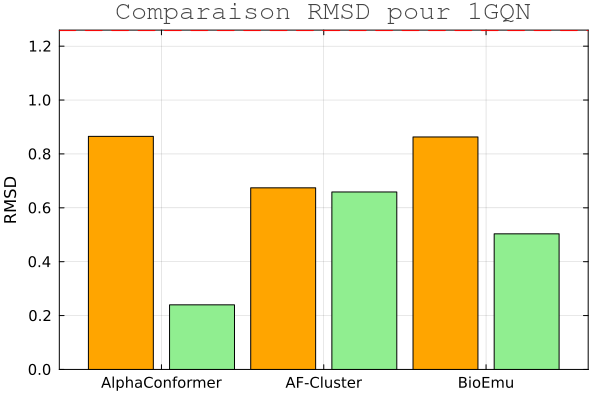

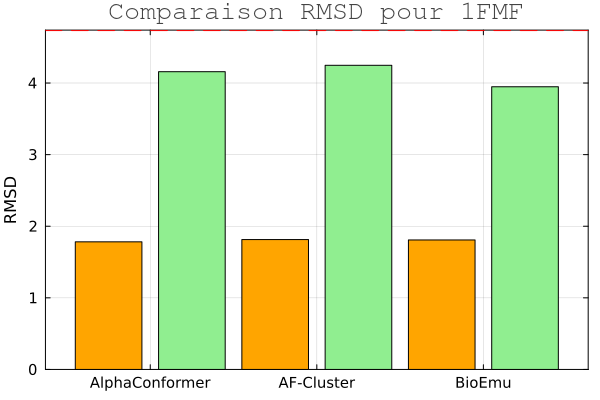

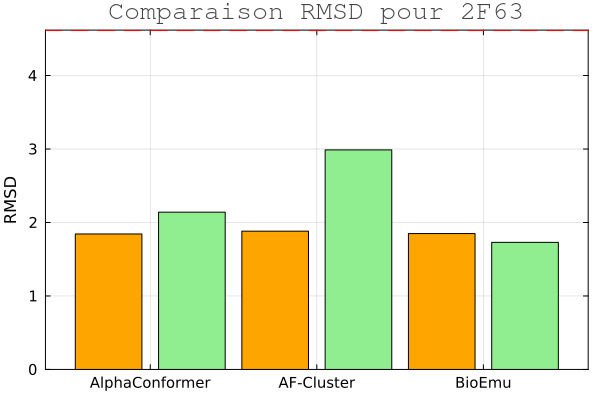

[0.8652069734807323, 0.6742237495595886, 0.8629961461545943]
Any[0.8652069734807323, 0.23974488410479472, 0.6742237495595886, 0.6587307733164905, 0.8629961461545943, 0.5035147390406718]
[1.7819712953444349, 1.8140130963001826, 1.8084596709469234]
Any[1.7819712953444349, 4.157857391655059, 1.8140130963001826, 4.246990354984768, 1.8084596709469234, 3.9477930473475036]
[1.8438419703418356, 1.881991976021262, 1.8489284123080396]
Any[1.8438419703418356, 2.140109811882182, 1.881991976021262, 2.987995570150976, 1.8489284123080396, 1.7296802963979692]


In [2]:
using DataFrames, StatsPlots, CSV

# Charger les données
df_path = "Compare_output_AF.csv"
df = DataFrame(CSV.File(df_path, comment="#", missingstring=["", "None"]))

# Trouver les noms PDB
pdb_names = ["1AKZ","1GQN","1FMF","2F63"]

# Couleurs personnalisées pour chaque groupe
colors_list = [
    :orange,          # 1er élément
    :lightgreen,    # 2
    :orange,          # 1er élément
    :lightgreen, 
    :orange,          # 1er élément
    :lightgreen,         # 7
]
line_color = :red

for pdb in pdb_names
    df_subset = filter(row -> row.File == pdb &&
    (row.Folder == pdb || row.Folder == pdb * "_AF_CLUSTER" || row.Folder == pdb * "_BIOEMU"), df)
    n = nrow(df_subset)
    labels = String.(df_subset.File)
    min_apo_vals = df_subset.min_apo
    min_holo_vals = df_subset.min_holo
    rmsd_val = first(df_subset.rmsd_apo_holo)
    all_vals=[]
    println(min_apo_vals)
    for i in 1:length(min_apo_vals)
        push!(all_vals,min_apo_vals[i])
        push!(all_vals,min_holo_vals[i])
    end
    println(all_vals)
    # Barplot simple
    xticks_pos = [2i-0.5 for i in 1:length(all_vals)]
    xticks_labels = ["AlphaConformer", "AF-Cluster", "BioEmu"]
    p = bar(
        1:(2n),
        all_vals,
        bar_width = 0.8,
        c = colors_list[1:2n],  # Trim la liste à la bonne taille
        legend = false,
        xticks = (xticks_pos, xticks_labels),
        ylabel = "RMSD",
        title = "Comparaison RMSD pour $pdb",
        framestyle = :box,
        titlefont = font(14, "Arial"),
        tickfont = font(10)
    )

    
    # Ligne horizontale
    hline!(p, [rmsd_val], color = line_color, lw = 2, linestyle = :dash, label = "rmsd_apo_holo")

    


    display(p)
end


g = "AlphaConformer min_apo"
idx = [1, 7, 13, 19]
y_mean = 1.257075083953428
g = "AlphaConformer min_holo"
idx = [2, 8, 14, 20]
y_mean = 1.8951565328183637
g = "AF-Cluster min_apo"
idx = [3, 9, 15, 21]
y_mean = 1.6617332361762724
g = "AF-Cluster min_holo"
idx = [4, 10, 16, 22]
y_mean = 2.4723244398689532
g = "BioEmu min_apo"
idx = [5, 11, 17, 23]
y_mean = 1.2824870338189478
g = "BioEmu min_holo"
idx = [6, 12, 18, 24]
y_mean = 1.7637935164150846


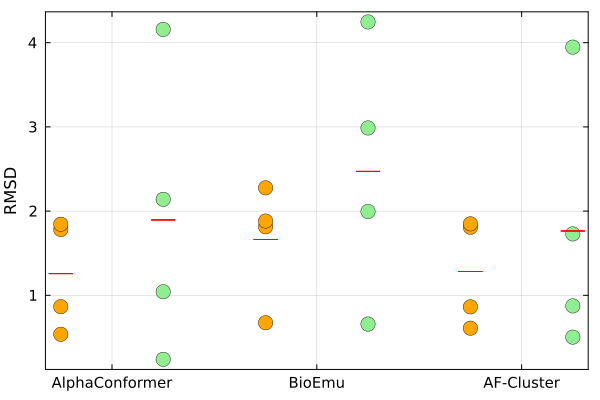

In [33]:
using StatsPlots
using Statistics

method_labels = String[]
value_types = String[]
values = Float64[]
for pdb in pdb_names
    df_subset = filter(row -> row.File == pdb &&
        (row.Folder == pdb || row.Folder == pdb * "_AF_CLUSTER" || row.Folder == pdb * "_BIOEMU"), df)

    # Préparer les données
    
    for row in eachrow(df_subset)
        if row.Folder == pdb
            push!(method_labels, "AlphaConformer")
            push!(value_types, "min_apo")
            push!(values, row.min_apo)
            push!(method_labels, "AlphaConformer")
            push!(value_types, "min_holo")
            push!(values, row.min_holo)
        elseif row.Folder == pdb * "_BIOEMU"
            push!(method_labels, "BioEmu")
            push!(value_types, "min_apo")
            push!(values, row.min_apo)
            push!(method_labels, "BioEmu")
            push!(value_types, "min_holo")
            push!(values, row.min_holo)
        elseif row.Folder == pdb * "_AF_CLUSTER"
            push!(method_labels, "AF-Cluster")
            push!(value_types, "min_apo")
            push!(values, row.min_apo)
            push!(method_labels, "AF-Cluster")
            push!(value_types, "min_holo")
            push!(values, row.min_holo)
        end
    end
end
# Grouper pour scatter plot
group = [method_labels[i] * " " * value_types[i] for i in 1:length(values)]

# Créer un vecteur de couleurs alternées orange/vert
point_colors = [i % 2 == 1 ? :orange : :lightgreen for i in 1:length(values)]
xticks_pos = [2i-1.0 for i in 1:length(group)]
xticks_labels = ["AlphaConformer", "BioEmu", "AF-Cluster"]

p = scatter(
    group, values;
    color=point_colors,
    markerstrokewidth=0.5,
    markersize=8,
    legend=false,
    ylabel="RMSD",
    framestyle=:box,
    titlefont=font(14, "Arial"),
    tickfont=font(10),
    xticks = (xticks_pos, xticks_labels)
)

moyenne=[]
for g in unique(group)
    @show g
    idx = findall(x -> x == g, group)
    @show idx
    y_mean = mean(values[idx])
    @show y_mean
    push!(moyenne, y_mean)
end
scatter!(group, moyenne; marker=:hline, color=:red, markersize=12, label=false)
display(p)


# Test set

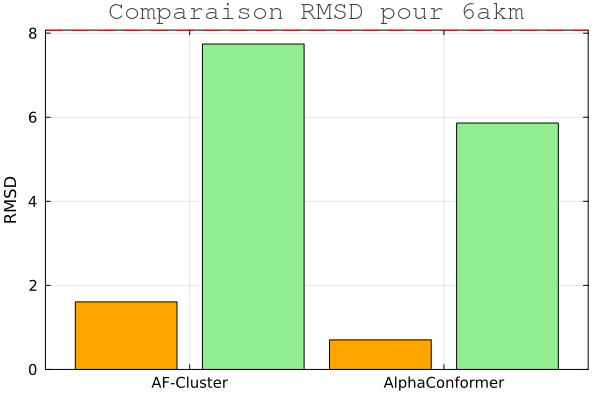

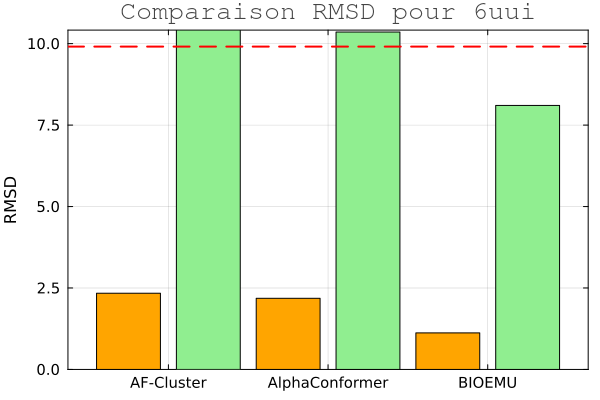

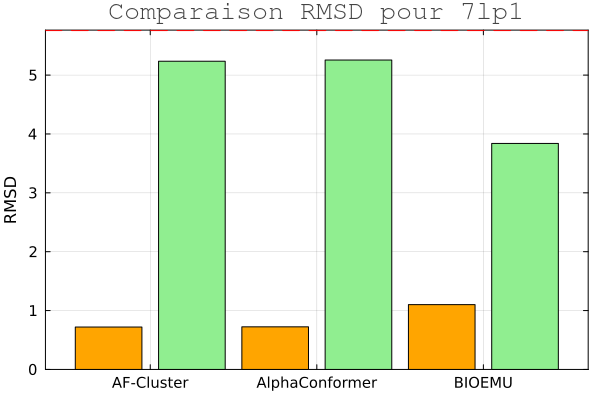

[1.6067996631750938, 0.7029702006436269]
Any[1.6067996631750938, 7.740973296207076, 0.7029702006436269, 5.86151386687832]
[2.3402248039314766, 2.184382291490875, 1.1224133121242528]
Any[2.3402248039314766, 10.415996885022125, 2.184382291490875, 10.355730970292841, 1.1224133121242528, 8.103615177496142]
[0.7200767426937031, 0.7238010661791673, 1.1015222611486442]
Any[0.7200767426937031, 5.23539634265103, 0.7238010661791673, 5.255696982644443, 1.1015222611486442, 3.8393273603410654]
[3.1832849137934187, 3.087080506681247, 2.7822860229520803]
Any[3.1832849137934187, 2.4437241734842847, 3.087080506681247, 2.2677150970630287, 2.7822860229520803, 1.9576152402169502]


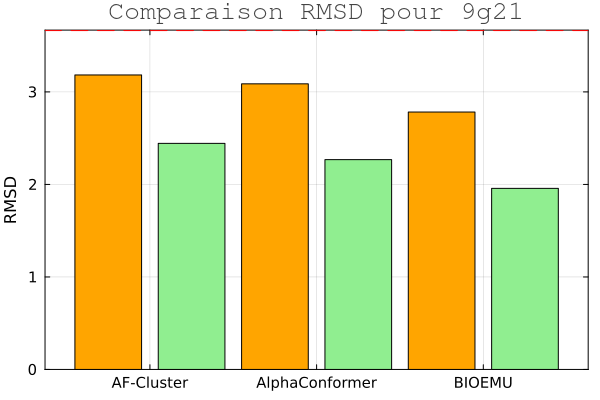

In [3]:
using DataFrames, StatsPlots, CSV

# Charger les données
df_path = "Compare_output_AF_test_set.csv"
df = DataFrame(CSV.File(df_path, comment="#", missingstring=["", "None"]))

# Trouver les noms PDB
pdb_names = ["6akm","6uui","7lp1","9g21"]

# Couleurs personnalisées pour chaque groupe
colors_list = [
    :orange,          # 1er élément
    :lightgreen,    # 2
    :orange,          # 1er élément
    :lightgreen, 
    :orange,          # 1er élément
    :lightgreen,         # 7
]
line_color = :red

for pdb in pdb_names
    df_subset = filter(row -> row.File == pdb &&
    (row.Folder == pdb*"_AlphaConformer" || row.Folder == pdb * "_AF_CLUSTER" || row.Folder == pdb * "_BIOEMU_MSA"), df)
    n = nrow(df_subset)
    labels = String.(df_subset.File)
    min_apo_vals = df_subset.min_apo
    min_holo_vals = df_subset.min_holo
    rmsd_val = first(df_subset.rmsd_apo_holo)
    all_vals=[]
    println(min_apo_vals)
    for i in 1:length(min_apo_vals)
        push!(all_vals,min_apo_vals[i])
        push!(all_vals,min_holo_vals[i])
    end
    println(all_vals)
    # Barplot simple
    xticks_pos = [2i-0.5 for i in 1:length(all_vals)]
    xticks_labels = ["AF-Cluster", "AlphaConformer", "BIOEMU"]
    p = bar(
        1:(2n),
        all_vals,
        bar_width = 0.8,
        c = colors_list[1:2n],  # Trim la liste à la bonne taille
        legend = false,
        xticks = (xticks_pos, xticks_labels),
        ylabel = "RMSD",
        title = "Comparaison RMSD pour $pdb",
        framestyle = :box,
        titlefont = font(14, "Arial"),
        tickfont = font(10)
    )

    
    # Ligne horizontale
    hline!(p, [rmsd_val], color = line_color, lw = 2, linestyle = :dash, label = "rmsd_apo_holo")

    


    display(p)
end


g = "AlphaConformer min_apo"
idx = [1, 7, 13, 19, 25]
y_mean = 6.64244652284065
g = "AlphaConformer min_holo"
idx = [2, 8, 14, 20, 26]
y_mean = 10.058067798886507
g = "BioEmu min_apo"
idx = [3, 9, 15, 21, 27]
y_mean = 1.257061674458555
g = "BioEmu min_holo"
idx = [4, 10, 16, 22, 28]
y_mean = 4.296893289262093
g = "AF-Cluster min_apo"
idx = [5, 11, 17, 23]
y_mean = 2.476019520376942
g = "AF-Cluster min_holo"
idx = [6, 12, 18, 24]
y_mean = 5.45947994816755


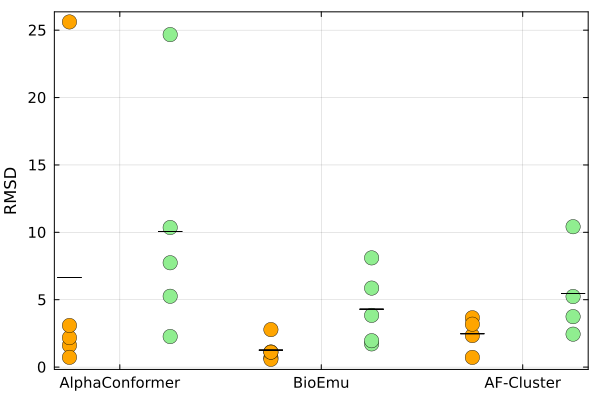

In [3]:
using StatsPlots
using Statistics

method_labels = String[]
value_types = String[]
values = Float64[]
for pdb in pdb_names
    df_subset = filter(row -> row.File == pdb &&
        (row.Folder == pdb*"_AlphaConformer" || row.Folder == pdb * "_AF_CLUSTER" || row.Folder == pdb * "_BIOEMU_MSA"), df)

    # Préparer les données
    
    for row in eachrow(df_subset)
        if row.Folder == pdb*"_AlphaConformer"
            push!(method_labels, "AlphaConformer")
            push!(value_types, "min_apo")
            push!(values, row.min_apo)
            push!(method_labels, "AlphaConformer")
            push!(value_types, "min_holo")
            push!(values, row.min_holo)
        elseif row.Folder == pdb * "_BIOEMU_MSA"
            push!(method_labels, "BioEmu")
            push!(value_types, "min_apo")
            push!(values, row.min_apo)
            push!(method_labels, "BioEmu")
            push!(value_types, "min_holo")
            push!(values, row.min_holo)
        elseif row.Folder == pdb * "_AF_CLUSTER"
            push!(method_labels, "AF-Cluster")
            push!(value_types, "min_apo")
            push!(values, row.min_apo)
            push!(method_labels, "AF-Cluster")
            push!(value_types, "min_holo")
            push!(values, row.min_holo)
        end
    end
end
# Grouper pour scatter plot
group = [method_labels[i] * " " * value_types[i] for i in 1:length(values)]

# Créer un vecteur de couleurs alternées orange/vert
point_colors = [i % 2 == 1 ? :orange : :lightgreen for i in 1:length(values)]
xticks_pos = [2i-1.0 for i in 1:length(group)]
xticks_labels = ["AlphaConformer","BioEmu","AF-Cluster" ]

p = scatter(
    group, values;
    color=point_colors,
    markerstrokewidth=0.5,
    markersize=8,
    legend=false,
    ylabel="RMSD",
    framestyle=:box,
    titlefont=font(14, "Arial"),
    tickfont=font(10),
    xticks = (xticks_pos, xticks_labels)
)

moyenne=[]
for g in unique(group)
    @show g
    idx = findall(x -> x == g, group)
    @show idx
    y_mean = mean(values[idx])
    @show y_mean
    push!(moyenne, y_mean)
end
scatter!(group, moyenne; marker=:hline, color=:black, markersize=12, label=false)
display(p)


In [ ]:
using StatsPlots
using Statistics

method_labels = String[]
value_types = String[]
values = Float64[]
nb_cluster=Dict{Int64, Float64}()
pdbs=[]
for pdb in pdb_names
    df_subset = filter(row -> row.File == pdb &&
        (row.Folder == pdb*"_AlphaConformer" || row.Folder == pdb * "_AF_CLUSTER" || row.Folder == pdb * "_BIOEMU_MSA"), df)

    # Préparer les données
    
    for row in eachrow(df_subset)
        
        if row.Folder == pdb*"_AlphaConformer"
            push!(pdbs,pdb)
            push!(method_labels, "AlphaConformer")
            push!(value_types, "min_apo")
            push!(values, row.min_apo)
            push!(pdbs,pdb)
            push!(method_labels, "AlphaConformer")
            push!(value_types, "min_holo")
            push!(values, row.min_holo)
            nb_cluster[row.Nombre_cluster] = pdb # ou une autre valeur
        elseif row.Folder == pdb * "_BIOEMU_MSA"
            push!(pdbs,pdb)
            push!(method_labels, "BioEmu")
            push!(value_types, "min_apo")
            push!(values, row.min_apo)
            push!(pdbs,pdb)
            push!(method_labels, "BioEmu")
            push!(value_types, "min_holo")
            push!(values, row.min_holo)
        elseif row.Folder == pdb * "_AF_CLUSTER"
            push!(pdbs,pdb)
            push!(method_labels, "AF-Cluster")
            push!(value_types, "min_apo")
            push!(values, row.min_apo)
            push!(pdbs,pdb)
            push!(method_labels, "AF-Cluster")
            push!(value_types, "min_holo")
            push!(values, row.min_holo)
        end
    end
end
# Grouper pour scatter plot
@show nb_cluster
clusters = sort(nb_cluster.keys)
group = [method_labels[i] * " " * value_types[i] for i in 1:length(values)]
clusters = sort(unique(nb_cluster))

# Pour chaque méthode et chaque type (min_apo, min_holo), calculer la moyenne pour chaque nb_cluster
methods = ["AlphaConformer", "BioEmu", "AF-Cluster"]
colors = [:orange, :green, :blue]

for value_type in ["min_apo", "min_holo"]
    p = plot(title="Moyenne $value_type en fonction du nombre de clusters",
             xlabel="Nombre de clusters", ylabel="RMSD", legend=:topright)
    for (i, method) in enumerate(methods)
        y = Float64[]
        for cl in clusters
            # Sélectionner les valeurs correspondant à la méthode, au type et au nombre de clusters
            idx = findall(x -> method_labels[x] == method && value_types[x] == value_type && nb_cluster[x] == cl, 1:length(values))
            if !isempty(idx)
                push!(y, mean(values[idx]))
            else
                push!(y, NaN) # ou missing si tu préfères
            end
        end
        plot!(clusters, y; marker=:circle, color=colors[i], label=method, lw=2)
    end
    display(p)
end


BoundsError: BoundsError: attempt to access 4-element Vector{Any} at index [7]

# First result

In [ ]:
# Créer un graphique pour chaque PDB
for pdb in pdb_names
    # Sous-dataframe correspondant à ce PDB
    df_subset = filter(row -> startswith(row.File, pdb), df)
    # Création des données pour le barplot
    labels = String.(df_subset.File)
    min_apo_vals = df_subset.mean_apo
    min_holo_vals = df_subset.mean_holo
    rmsd_val = first(df_subset.rmsd_apo_holo)  # identique pour tous les row
    # Barplot groupé
    p = groupedbar(
        [min_apo_vals min_holo_vals],
        bar_position = :dodge,
        label = ["min_apo" "min_holo"],
        title = "Comparaison mean RMSD pour $pdb",
        xlabel = "File",
        ylabel = "RMSD",
        lw = 0,
        c = [apo_color holo_color],
        legend = :outertopright,
        titlefont = font(14, "Arial"),
        tickfont = font(10),
        legendfontsize = 10,
        framestyle = :box
    )

    # Ligne horizontale rouge pour rmsd_apo_holo
    hline!(p, [rmsd_val], color = line_color, lw = 2, linestyle = :dash, label = "rmsd_apo_holo")

    # Annotation : Folders pour chaque File
    for (i, row) in enumerate(eachrow(df_subset))
        annotate!(p, (i, max(row.min_apo, row.min_holo) + 0.2, text(row.File, :black,5)))
    end

    # Affiche ou sauvegarde
    display(p)
    # savefig(p, "rmsd_plot_$pdb.png")  # optionnel
end


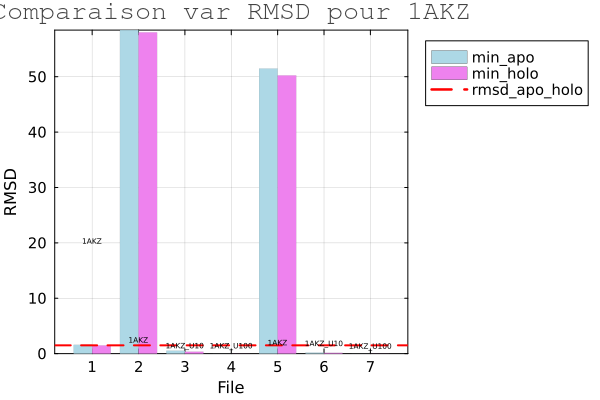

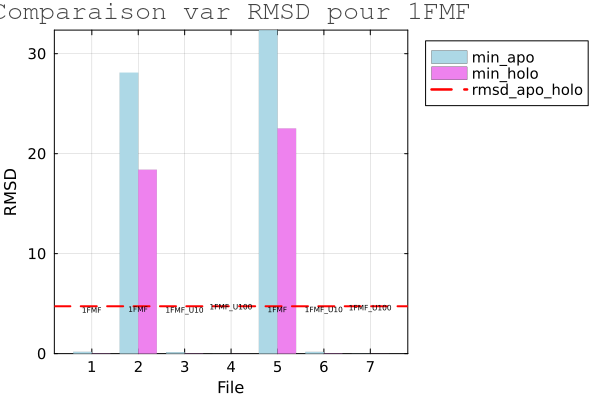

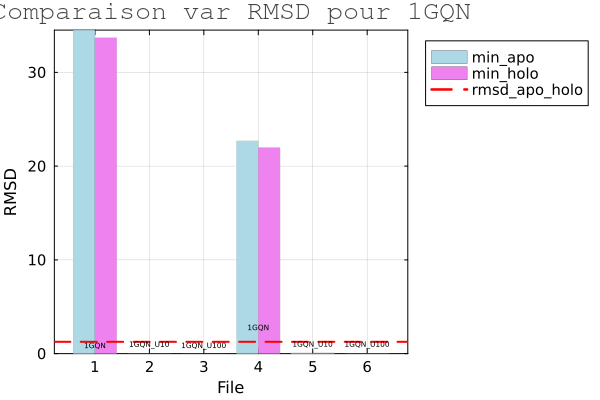

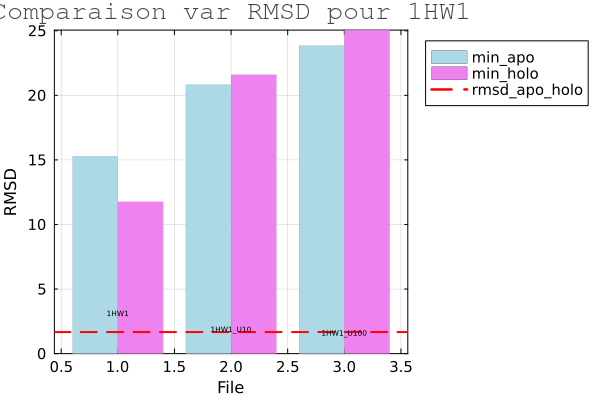

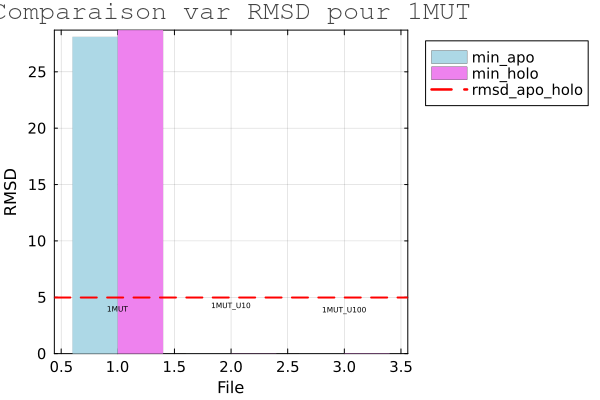

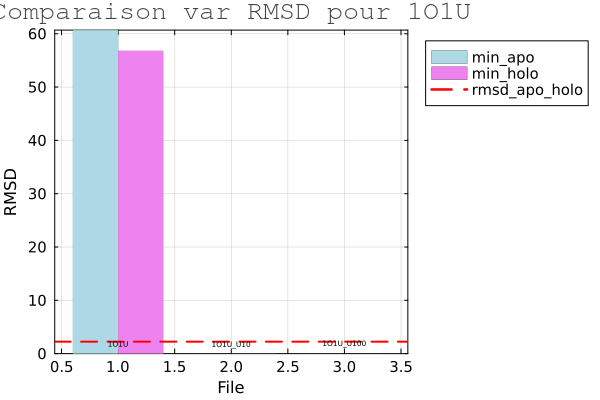

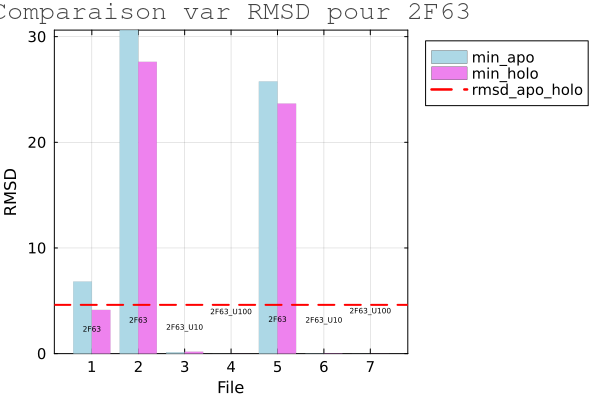

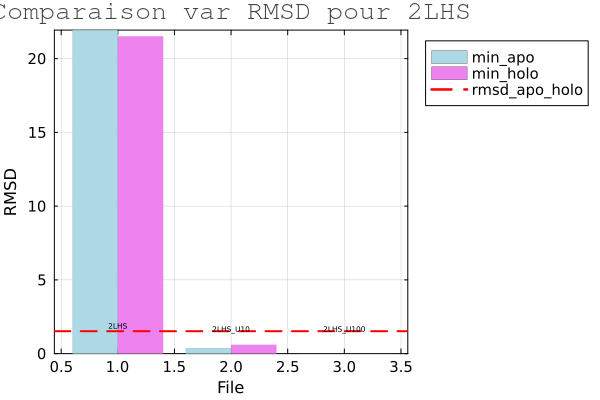

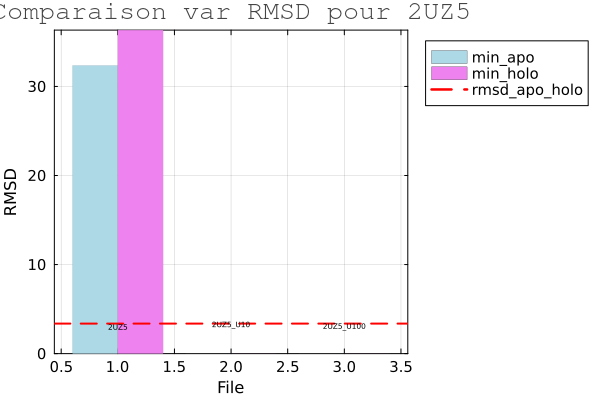

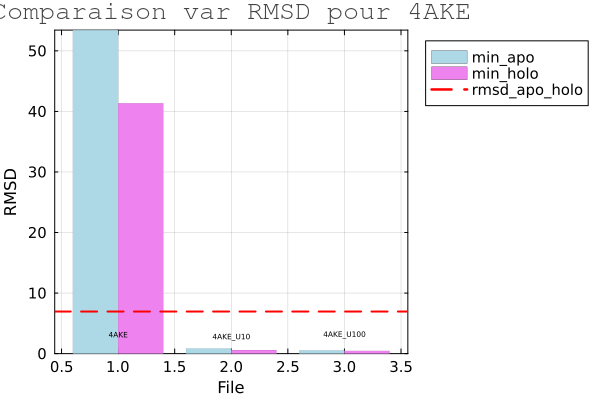

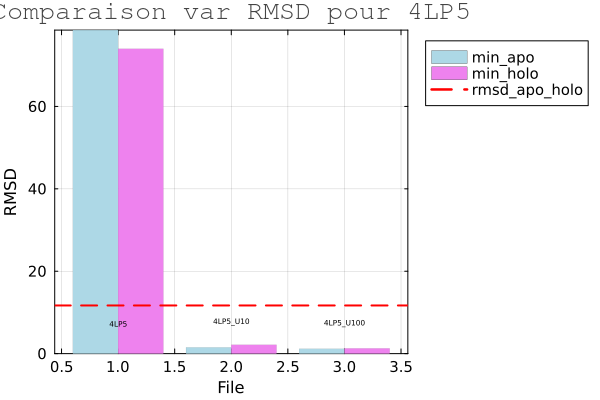

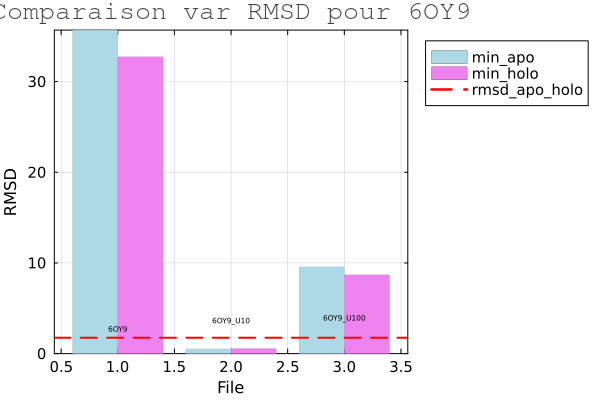

In [16]:
# Créer un graphique pour chaque PDB
for pdb in pdb_names
    # Sous-dataframe correspondant à ce PDB
    df_subset = filter(row -> startswith(row.File, pdb), df)
    # Création des données pour le barplot
    labels = String.(df_subset.File)
    min_apo_vals = df_subset.var_apo
    min_holo_vals = df_subset.var_holo
    rmsd_val = first(df_subset.rmsd_apo_holo)  # identique pour tous les row
    # Barplot groupé
    p = groupedbar(
        [min_apo_vals min_holo_vals],
        bar_position = :dodge,
        label = ["min_apo" "min_holo"],
        title = "Comparaison var RMSD pour $pdb",
        xlabel = "File",
        ylabel = "RMSD",
        lw = 0,
        c = [apo_color holo_color],
        legend = :outertopright,
        titlefont = font(14, "Arial"),
        tickfont = font(10),
        legendfontsize = 10,
        framestyle = :box
    )

    # Ligne horizontale rouge pour rmsd_apo_holo
    hline!(p, [rmsd_val], color = line_color, lw = 2, linestyle = :dash, label = "rmsd_apo_holo")

    # Annotation : Folders pour chaque File
    for (i, row) in enumerate(eachrow(df_subset))
        annotate!(p, (i, max(row.min_apo, row.min_holo) + 0.2, text(row.File, :black,5)))
    end

    # Affiche ou sauvegarde
    display(p)
    # savefig(p, "rmsd_plot_$pdb.png")  # optionnel
end
